#Algoritmo de clasificación para Pokemón
Clasifica el tipo de pokemón de acuerdo con sus puntos de combate (PC), su estado de salud (PS), su peso y su altura

In [ ]:
#Primero importar las librerias para leer la base de datos
import pandas as pd

In [ ]:
datos=pd.read_excel('/content/drive/MyDrive/Tec/Tec_3D/pokemon_respuesta.xlsx')

In [ ]:
datos

,Nombre,Tipo,PC (puntos de combate),PS (puntos de salud),Peso,Altura (m)
0,Whismur,normal,187,74,9.04,0.46
1,Spearow,normal,188,48,2.49,0.31
2,Eeevee,normal,197,50,7.28,0.30
3,Venonat,bicho,216,60,36.98,1.09
4,Weedle,bicho,24,27,2.27,0.23
5,Caterpie,bicho,13,23,3.07,0.33
6,Paras,bicho,63,24,6.40,0.33
7,Fearow,normal,305,55,33.41,1.03
8,Pidgeotto,normal,329,73,39.33,1.20
9,Meowth,normal,29,21,3.52,0.41


In [ ]:
#La instrucción iloc nos sirve para seleccionar filas y/0 columnas de una base de datos.
#Ejemplo: Seleccionemos la fila cero de la base de datos
datos.iloc[0,:]

,0
Nombre,Whismur
Tipo,normal
PC (puntos de combate),187
PS (puntos de salud),74
Peso,9.04
Altura (m),0.46


In [ ]:
#Seleccionemos la columna uno de la base de datos
datos.iloc[:,1]

,Tipo
0,normal
1,normal
2,normal
3,bicho
4,bicho
5,bicho
6,bicho
7,normal
8,normal
9,normal


Paso 1: Seleccionar las variables predictoras (son las que se ocupan para realizar la predicción)

In [ ]:
var_predictoras=datos.iloc[:,2:]

In [ ]:
var_predictoras

,PC (puntos de combate),PS (puntos de salud),Peso,Altura (m)
0,187,74,9.04,0.46
1,188,48,2.49,0.31
2,197,50,7.28,0.30
3,216,60,36.98,1.09
4,24,27,2.27,0.23
5,13,23,3.07,0.33
6,63,24,6.40,0.33
7,305,55,33.41,1.03
8,329,73,39.33,1.20
9,29,21,3.52,0.41


Paso 2: seleccionar la variable que se desea predecir, es decir, la varable de respuesta

In [ ]:
var_respuesta=datos.iloc[:,1]

In [ ]:
var_respuesta

,Tipo
0,normal
1,normal
2,normal
3,bicho
4,bicho
5,bicho
6,bicho
7,normal
8,normal
9,normal


El método que vamos a utilizar para hacer la clasificación es un árbol de decisión. Primero importemos las librerias correspondientes.

In [ ]:
#Para el arbol de decisión de sklearn se importa DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
arbol=DecisionTreeClassifier()

In [ ]:
#Ajuste del modelo
#Entrenamiento del modelo (entrenamiento del árbol)
arbol.fit(var_predictoras,var_respuesta)

DecisionTreeClassifier()

In [ ]:
# 	PC (puntos de combate), 	PS (puntos de salud), 	Peso, 	Altura (m)
arbol.predict([[190,71,1.01,0.46]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array(['normal'], dtype=object)

Hagamos que el modelo realice una predicción sobre los datos que conocemos

In [ ]:
predicciones=arbol.predict(var_predictoras)

In [ ]:
predicciones

array(['normal', 'normal', 'normal', 'bicho', 'bicho', 'bicho', 'bicho',
       'normal', 'normal', 'normal', 'normal'], dtype=object)

##Matriz de confusión

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Revisar el orden de las clases
print(arbol.classes_)

['bicho' 'normal']


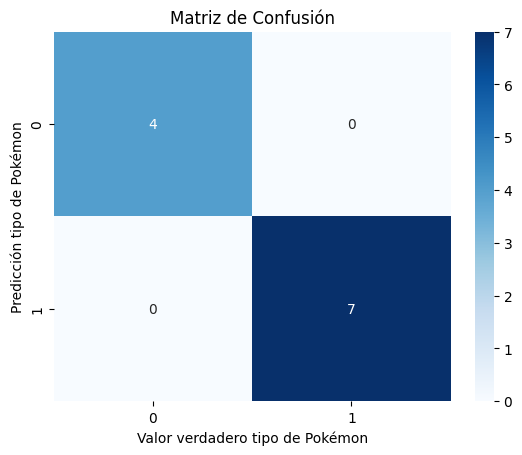

In [ ]:
# Crear la matriz de confusión
matriz_confusion = confusion_matrix(var_respuesta, predicciones)
# Mostrar la matriz de confusión como un heatmap
sns.heatmap(matriz_confusion, annot=True, cmap='Blues')
#sns.heatmap(matriz_confusion, annot=True, fmt='d', cmap='Blues')
# Configurar los nombres de los ejes
#plt.xticks([0.5,1.5], ['Bicho','Normal'])
#plt.yticks([0.5,1.5],['Bicho','Normal'])
plt.ylabel('Predicción tipo de Pokémon')
plt.xlabel('Valor verdadero tipo de Pokémon')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
#Exactitud del modelo
print(f'Exactitud del modelo {arbol.score(var_predictoras,predicciones)}')

Exactitud del modelo 1.0


**Observar el árbol de decisión**

##Explicación del arbol de decisión
El código que proporcionaste es parte de la biblioteca `scikit-learn` en Python y se utiliza para exportar un árbol de decisión entrenado a un archivo en formato DOT. El archivo DOT se puede visualizar posteriormente con herramientas como Graphviz para comprender la estructura del árbol de decisión. Aquí tienes una explicación de los parámetros utilizados en la función `export_graphviz`:

- `arbol`: Debe ser un objeto de árbol de decisión previamente entrenado utilizando el módulo `DecisionTreeClassifier` de scikit-learn.
- `out_file`: Es el nombre del archivo de salida en formato DOT donde se exportará el árbol.
- `class_names`: Una lista que especifica las etiquetas de clase o categorías del problema de clasificación. En tu ejemplo, se utilizan las etiquetas 'benigno' y 'maligno' para describir las clases.
- `feature_names`: Una lista de nombres de características o características utilizadas en el árbol de decisión. En tu ejemplo, `df.columns[2:]` se utiliza para tomar los nombres de las características a partir de la tercera columna de tu DataFrame `df`.
- `impurity`: Si se establece en `True`, muestra la impureza de los nodos en el árbol (agraga color a los nodos del arbol)
- `filled`: Si se establece en `True`, colorea los nodos en función de la clase mayoritaria.

Asegúrate de que `arbol` se haya ajustado previamente a tus datos utilizando un clasificador de árbol de decisión. Luego, al ejecutar este código, se creará un archivo llamado 'arbol.dot' que contendrá la representación en formato DOT del árbol de decisión. Para visualizarlo, puedes utilizar la herramienta Graphviz. Por ejemplo, para convertir el archivo DOT en una imagen PNG, puedes usar el siguiente comando en la línea de comandos:

```
dot -Tpng arbol.dot -o arbol.png
```

Esto generará un archivo de imagen llamado 'arbol.png' que mostrará la representación visual del árbol de decisión.

In [ ]:
from sklearn.tree import export_graphviz
export_graphviz(arbol, out_file='arbol.dot', class_names=['Bicho', 'Normal'], feature_names=datos.columns[2:], impurity=False, filled=True)

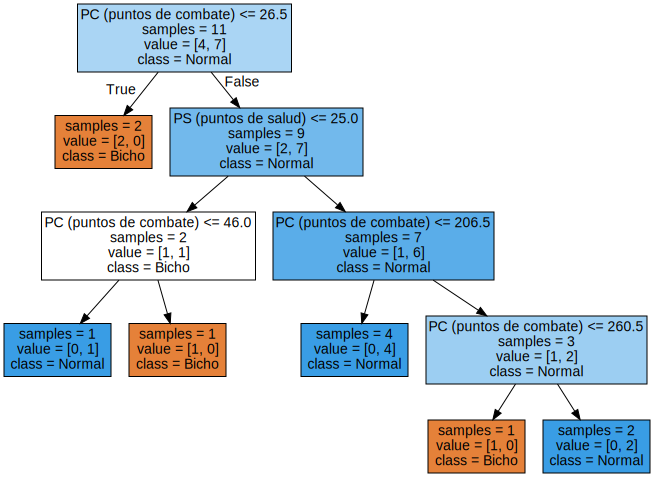

In [ ]:
#Visualizar el arbol de decisión ya entrenado
#Ej.: en el nodo raíz value = [4, 7] → hay 4 ejemplos de Bicho y 7 de Normal. De un total de 11 muestras asi fue como se dividieron las clases
#class = X: clase predicha por el nodo (la mayoría de los ejemplos en ese nodo). Ej.: si hay más Normal que Bicho, class = Normal.
#Condición: PC <= 26.5
#samples = 11 (el total de ejemplos que entrenaron este árbol)
#value = [4, 7] → 4 Bicho, 7 Normal
#class = Normal (porque 7 > 4)
import graphviz
with open("arbol.dot") as f:
  dot_graph=f.read()
graphviz.Source(dot_graph)

In [ ]:
#Guardar en HTML

from google.colab import files


from nbconvert import HTMLExporter


import nbformat



# Cargar el archivo .ipynb en el cuaderno


direccion_nombre ='/content/drive/MyDrive/Tec/Tec_3D/Pokemon.ipynb' # Reemplaza con el nombre de tu cuaderno



# Leer el archivo .ipynb


with open(direccion_nombre) as f:

     contenido = f.read()




# Convertir a HTML


leer_cuaderno = nbformat.reads(contenido, as_version=4)

html_exportar = HTMLExporter()

#html_exporter.exclude_input = False  # Excluye el código si es necesario

html_contenido, _ = html_exportar.from_notebook_node(leer_cuaderno)



# Guardar el archivo HTML


with open('/content/drive/MyDrive/Tec/Tec_3D/Pokemon.html', 'w') as f:

    f.write(html_contenido)



# Descargar el archivo HTML


files.download('/content/drive/MyDrive/Tec/Tec_3D/Pokemon.html')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>